# In-class demo for Lecture 17 – Spatial Statistics II (Spring 2026)
Topics: Spatial Interpolation, Variograms, and Kriging with the Meuse dataset.


In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Part 0 — Load Data
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Part 0 — Load Data")
print("=" * 60)

df = pd.read_csv('meuse.csv')
print(f"  meuse.csv: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"  Columns: {df.columns.tolist()}")
print(f"\n  Zinc summary:\n{df['zinc'].describe().to_string()}\n")

x      = df['x'].values
y      = df['y'].values
zinc   = df['zinc'].values
log_z  = np.log(zinc)
dist_m = df['dist.m'].values

# Domain mask (NetCDF)
ds          = xr.open_dataset('meuse_domain.nc')
xi          = ds['x'].values          # 40-m grid x coords (78,)
yi          = ds['y'].values          # 40-m grid y coords (104,)
domain_mask = ds['domain'].values.astype(bool)   # (104, 78)
XI, YI      = np.meshgrid(xi, yi)
print(f"  Domain grid: {len(xi)} x {len(yi)} cells at 40 m spacing")
print(f"  Cells in domain: {domain_mask.sum()}\n")

# River shapefile
gdf_riv = gpd.read_file('meuse_riv.shp')
print(f"  River shapefile loaded: {len(gdf_riv)} polygon(s)\n")

# Zoom extent
PAD  = 300
XMIN, XMAX = xi.min() - PAD, xi.max() + PAD
YMIN, YMAX = yi.min() - PAD, yi.max() + PAD

Part 0 — Load Data
  meuse.csv: 155 rows x 14 columns
  Columns: ['x', 'y', 'cadmium', 'copper', 'lead', 'zinc', 'elev', 'dist', 'om', 'ffreq', 'soil', 'lime', 'landuse', 'dist.m']

  Zinc summary:
count     155.000000
mean      469.716129
std       367.073788
min       113.000000
25%       198.000000
50%       326.000000
75%       674.500000
max      1839.000000

  Domain grid: 78 x 104 cells at 40 m spacing
  Cells in domain: 3103

  River shapefile loaded: 1 polygon(s)



In [3]:
# define some useful functions
def idw(values, power=2.5):
    """IDW on the domain grid; outside domain → NaN."""
    grid_pts = np.column_stack([XI.ravel(), YI.ravel()])
    D = cdist(grid_pts, np.column_stack([x, y]))
    D = np.where(D == 0, 1e-10, D)
    W = 1.0 / D**power
    W /= W.sum(axis=1, keepdims=True)
    Z = (W @ values).reshape(XI.shape)
    return np.where(domain_mask, Z, np.nan)

def add_river(ax):
    """Overlay river polygon and apply study-domain zoom."""
    gdf_riv.plot(ax=ax, color='#9ecae1', alpha=0.45, zorder=2)
    gdf_riv.boundary.plot(ax=ax, color='#2166ac', linewidth=1.2, zorder=3,
                          label='Meuse river')
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)

def map_plot(ax, Z, cmap, clabel, title):
    """pcolormesh + river overlay + colorbar."""
    Zm = np.ma.masked_invalid(Z)
    im = ax.pcolormesh(xi, yi, Zm, cmap=cmap, shading='nearest', zorder=1)
    add_river(ax)
    plt.colorbar(im, ax=ax, label=clabel, shrink=0.85)
    ax.set_title(title)
    ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
    ax.set_aspect('equal')

Part 1 — Visualise Zinc Concentrations


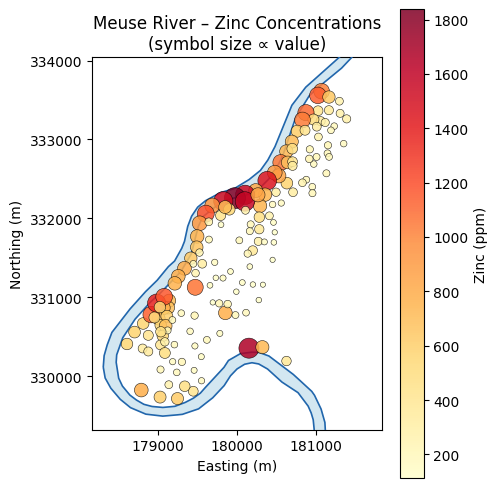

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Part 1 — Visualise Zinc Concentrations
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Part 1 — Visualise Zinc Concentrations")
print("=" * 60)

fig, ax = plt.subplots(figsize=(5, 7))
add_river(ax)
sc = ax.scatter(x, y, s=zinc / 8, c=zinc, cmap='YlOrRd',
                alpha=0.85, edgecolors='k', linewidths=0.4, zorder=4)
plt.colorbar(sc, ax=ax, label='Zinc (ppm)', shrink=0.7)
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
ax.set_title('Meuse River – Zinc Concentrations\n(symbol size ∝ value)')
ax.set_aspect('equal')
fig.tight_layout()

Part 2 — Inverse Distance Weighting (IDW, domain-masked)
  Raw zinc IDW range (in domain): 116.0 – 1833.5 ppm


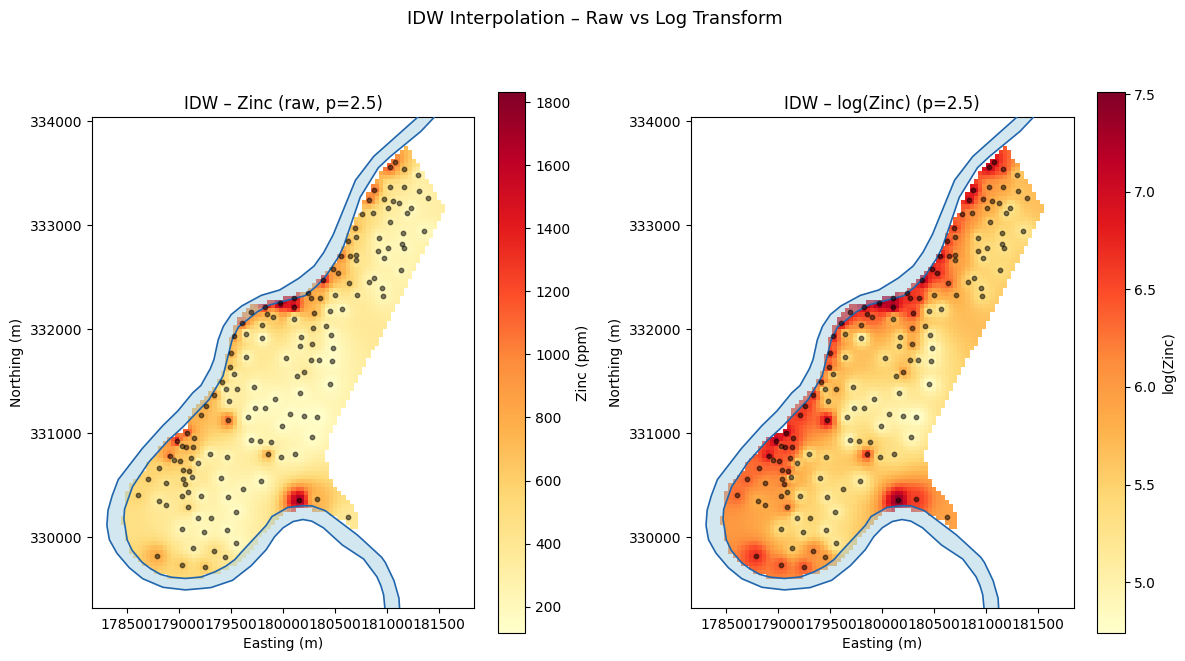

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Part 2 — IDW Interpolation (domain-masked)
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Part 2 — Inverse Distance Weighting (IDW, domain-masked)")
print("=" * 60)

ZI_raw = idw(zinc)
ZI_log = idw(log_z)
print(f"  Raw zinc IDW range (in domain): "
      f"{np.nanmin(ZI_raw):.1f} – {np.nanmax(ZI_raw):.1f} ppm")

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
map_plot(axes[0], ZI_raw, 'YlOrRd', 'Zinc (ppm)',    'IDW – Zinc (raw, p=2.5)')
map_plot(axes[1], ZI_log, 'YlOrRd', 'log(Zinc)',     'IDW – log(Zinc) (p=2.5)')
for ax in axes:
    ax.scatter(x, y, s=10, c='k', alpha=0.5, zorder=5)
fig.suptitle('IDW Interpolation – Raw vs Log Transform', fontsize=13)
fig.tight_layout()

Part 3 — Linear Model: log(Zinc) ~ sqrt(distance)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.630
Model:                            OLS   Adj. R-squared:                  0.627
Method:                 Least Squares   F-statistic:                     260.3
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           7.74e-35
Time:                        03:34:24   Log-Likelihood:                -91.898
No. Observations:                 155   AIC:                             187.8
Df Residuals:                     153   BIC:                             193.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

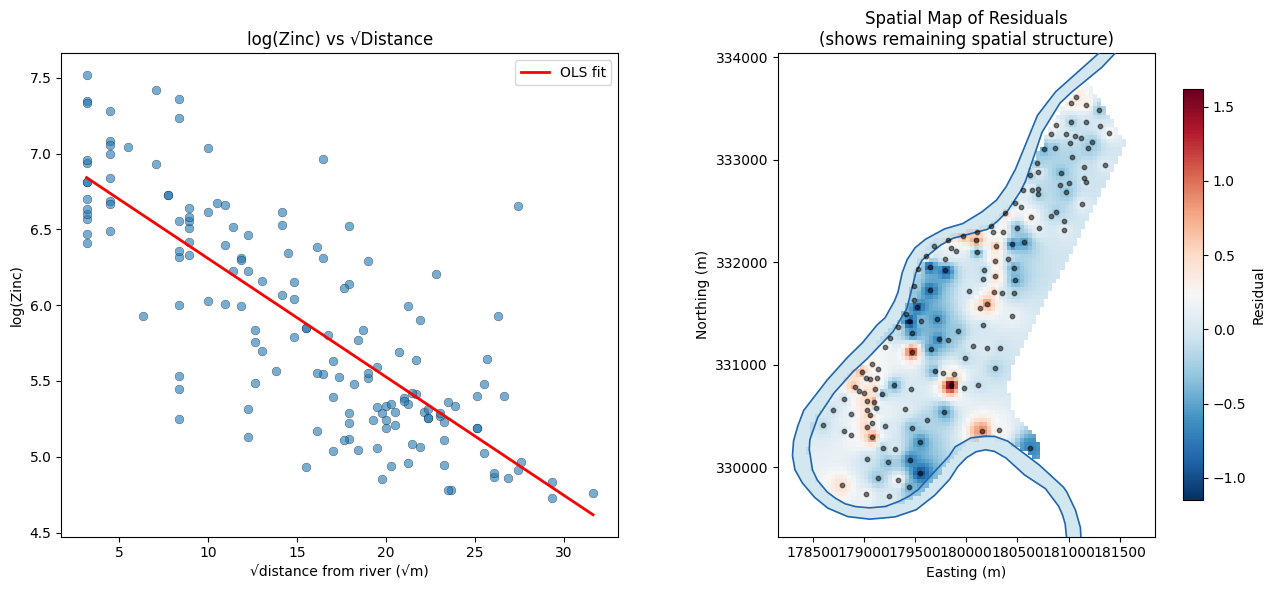

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Part 3 — Trend: log(Zinc) vs Distance + Residual Map
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Part 3 — Linear Model: log(Zinc) ~ sqrt(distance)")
print("=" * 60)

X_sm  = sm.add_constant(np.sqrt(dist_m))
model = sm.OLS(log_z, X_sm).fit()
print(model.summary())

fitted    = model.fittedvalues - model.fittedvalues.mean()
residuals = model.resid

ZI_res = idw(residuals)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# biplot (non-spatial)
axes[0].scatter(np.sqrt(dist_m), log_z, alpha=0.6, edgecolors='k',
                linewidths=0.3, s=40)
xl = np.linspace(np.sqrt(dist_m).min(), np.sqrt(dist_m).max(), 100)
axes[0].plot(xl, model.params[0] + model.params[1]*xl, 'r-', lw=2, label='OLS fit')
axes[0].set_xlabel('√distance from river (√m)')
axes[0].set_ylabel('log(Zinc)')
axes[0].set_title('log(Zinc) vs √Distance')
axes[0].legend()

# residuals map (domain-masked)
map_plot(axes[1], ZI_res, 'RdBu_r', 'Residual',
         'Spatial Map of Residuals\n(shows remaining spatial structure)')
axes[1].scatter(x, y, s=10, c='k', alpha=0.5, zorder=5)

fig.tight_layout()

Part 4 — Empirical Variogram of log(Zinc)
  Computing all pairwise distances ...
  Total pairs: 11,935
  Distance bins with data: 15


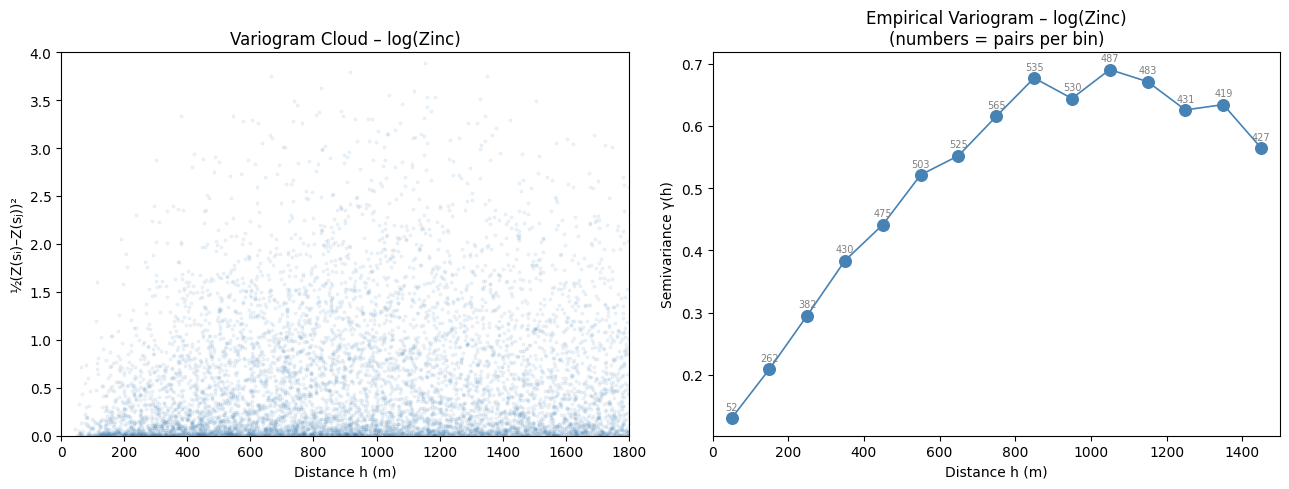

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Part 4 — Empirical Variogram
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Part 4 — Empirical Variogram of log(Zinc)")
print("=" * 60)

print("  Computing all pairwise distances ...")
n = len(df)
h_list, g_list = [], []
for i in range(n):
    for j in range(i + 1, n):
        h_ij = np.sqrt((x[i]-x[j])**2 + (y[i]-y[j])**2)
        g_ij = 0.5 * (log_z[i] - log_z[j])**2
        h_list.append(h_ij); g_list.append(g_ij)
h_arr = np.array(h_list); g_arr = np.array(g_list)
print(f"  Total pairs: {len(h_arr):,}")

bins = np.linspace(0, 1500, 16)
bin_centres, bin_gamma, bin_n = [], [], []
for k in range(len(bins) - 1):
    mask = (h_arr >= bins[k]) & (h_arr < bins[k+1])
    if mask.sum() > 5:
        bin_centres.append((bins[k]+bins[k+1]) / 2)
        bin_gamma.append(g_arr[mask].mean())
        bin_n.append(mask.sum())
print(f"  Distance bins with data: {len(bin_centres)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(h_arr, g_arr, alpha=0.08, s=4, c='steelblue')
axes[0].set_xlabel('Distance h (m)'); axes[0].set_ylabel('½(Z(sᵢ)–Z(sⱼ))²')
axes[0].set_title('Variogram Cloud – log(Zinc)')
axes[0].set_xlim(0, 1800); axes[0].set_ylim(0, 4)

axes[1].scatter(bin_centres, bin_gamma, s=70, c='steelblue', zorder=3)
axes[1].plot(bin_centres, bin_gamma, 'steelblue', lw=1.2)
for bc, bg, bn in zip(bin_centres, bin_gamma, bin_n):
    axes[1].annotate(str(bn), (bc, bg), textcoords='offset points',
                     xytext=(0, 6), ha='center', fontsize=7, color='gray')
axes[1].set_xlabel('Distance h (m)'); axes[1].set_ylabel('Semivariance γ(h)')
axes[1].set_title('Empirical Variogram – log(Zinc)\n(numbers = pairs per bin)')
axes[1].set_xlim(0, 1500)

fig.tight_layout()

Part 5 — Fitting a Spherical Variogram Model
  Auto-fitting spherical variogram via OrdinaryKriging ...
Plotting Enabled

Adjusting data for anisotropy...
Initializing variogram model...
Coordinates type: 'euclidean' 

Using 'spherical' Variogram Model
Partial Sill: 0.5442347128534295
Full Sill: 0.5587594504397868
Range: 714.2015978500682
Nugget: 0.014524737586357259 



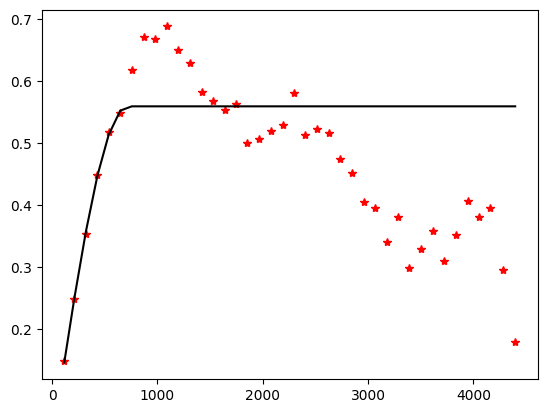

Calculating statistics on variogram model fit...

  Fitted Nugget = 0.0145
  Fitted Psill  = 0.5442
  Fitted Range  = 714.2 m
  Sill (total variance) = 0.559


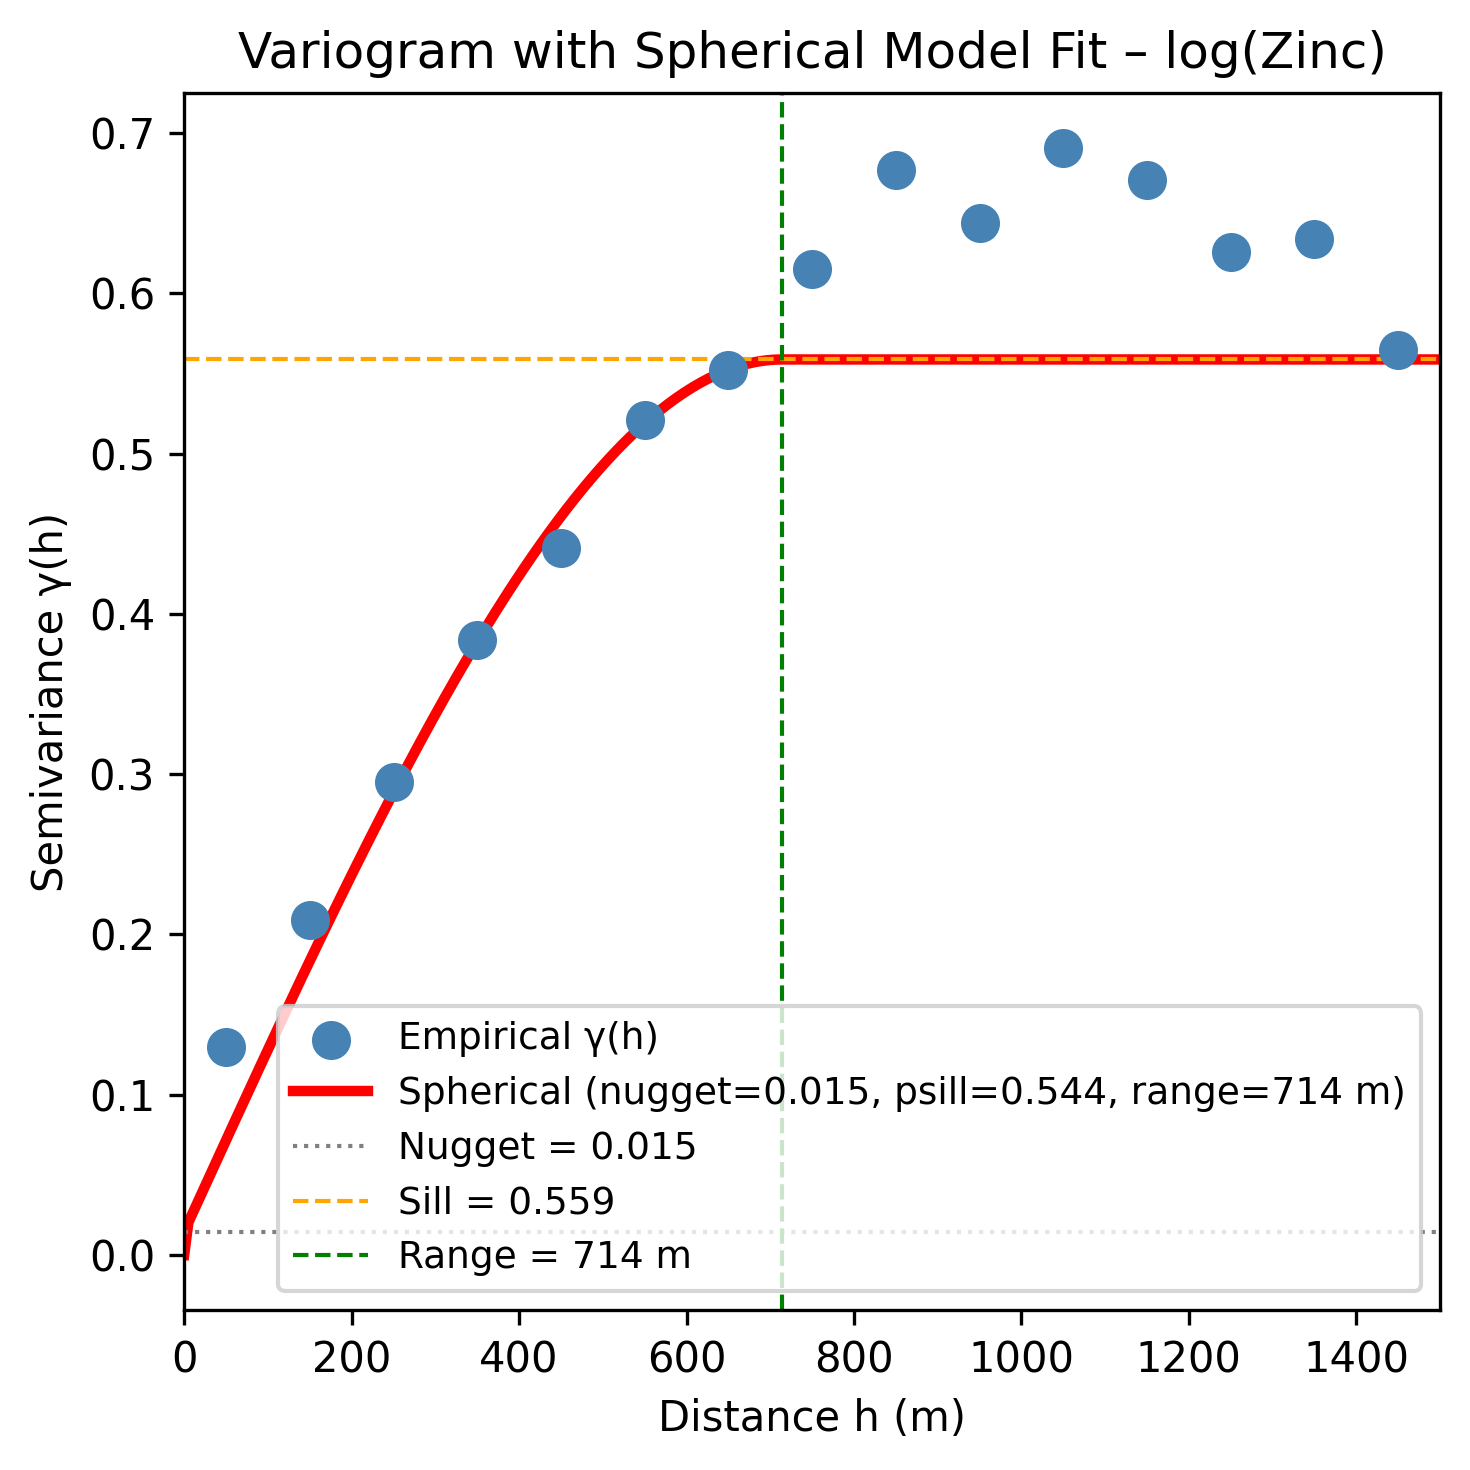

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Part 5 — Fitting a Variogram Model
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Part 5 — Fitting a Spherical Variogram Model")
print("=" * 60)

from pykrige.ok import OrdinaryKriging

def spherical_model(h, nugget, psill, range_):
    h = np.asarray(h, dtype=float)
    return np.where(h == 0, 0.0,
           np.where(h < range_,
                    nugget + psill * (1.5*(h/range_) - 0.5*(h/range_)**3),
                    nugget + psill))

# Let pykrige auto-fit the spherical variogram to the data (no variogram_parameters supplied).
# Internally it uses weighted least squares on the empirical variogram it computes from the
# sample points, which is exactly what we want to show students.
print("  Auto-fitting spherical variogram via OrdinaryKriging ...")
OK = OrdinaryKriging(
    x, y, log_z,
    variogram_model='spherical',
    nlags=40,
    weight=True,
    verbose=True, enable_plotting=True
)

# pykrige stores fitted params as [psill, range, nugget] for the spherical model
psill, range_, nugget = OK.variogram_model_parameters
print(f"\n  Fitted Nugget = {nugget:.4f}")
print(f"  Fitted Psill  = {psill:.4f}")
print(f"  Fitted Range  = {range_:.1f} m")
print(f"  Sill (total variance) = {nugget+psill:.3f}")

h_model = np.linspace(0, 1500, 300)
fig, ax = plt.subplots(figsize=(5, 5),dpi=300)
ax.scatter(bin_centres, bin_gamma, s=70, c='steelblue', zorder=3, label='Empirical γ(h)')
ax.plot(h_model, spherical_model(h_model, nugget, psill, range_),
        'r-', lw=2.5,
        label=f'Spherical (nugget={nugget:.3f}, psill={psill:.3f}, range={range_:.0f} m)')
ax.axhline(nugget, ls=':', c='gray', lw=1, label=f'Nugget = {nugget:.3f}')
ax.axhline(nugget+psill, ls='--', c='orange', lw=1, label=f'Sill = {nugget+psill:.3f}')
ax.axvline(range_, ls='--', c='green', lw=1, label=f'Range = {range_:.0f} m')
ax.set_xlabel('Distance h (m)'); ax.set_ylabel('Semivariance γ(h)')
ax.set_title('Variogram with Spherical Model Fit – log(Zinc)')
ax.set_xlim(0, 1500); ax.legend(fontsize=9)
fig.tight_layout()

Part 6 — Ordinary Kriging with pykrige (domain-masked)
Adjusting data for anisotropy...
Initializing variogram model...
Coordinates type: 'euclidean' 

Using 'spherical' Variogram Model
Partial Sill: 0.5442347128534295
Full Sill: 0.5587594504397868
Range: 714.2015978500682
Nugget: 0.014524737586357259 

Calculating statistics on variogram model fit...
Executing Ordinary Kriging...

  Prediction range (in domain): 4.755 – 7.491
  Std dev range (in domain):    0.175 – 0.707


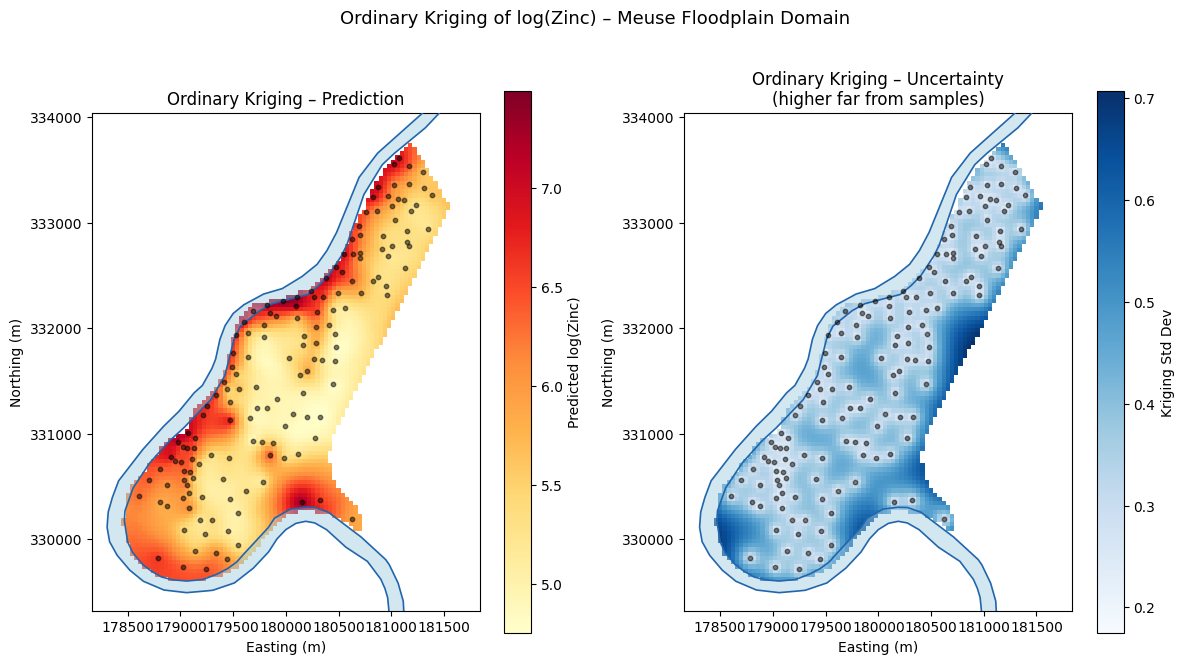

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Part 6 — Ordinary Kriging (domain-masked)
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Part 6 — Ordinary Kriging with pykrige (domain-masked)")
print("=" * 60)

from pykrige.ok import OrdinaryKriging

OK = OrdinaryKriging(
    x, y, log_z,
    variogram_model='spherical',
    variogram_parameters={'psill': psill, 'range': range_, 'nugget': nugget},
    verbose=True, enable_plotting=False
)

z_pred, z_var = OK.execute('grid', xi, yi)
z_pred = np.where(domain_mask, z_pred, np.nan)
z_std  = np.where(domain_mask, np.sqrt(z_var), np.nan)
print(f"  Prediction range (in domain): {np.nanmin(z_pred):.3f} – {np.nanmax(z_pred):.3f}")
print(f"  Std dev range (in domain):    {np.nanmin(z_std):.3f} – {np.nanmax(z_std):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
map_plot(axes[0], z_pred, 'YlOrRd', 'Predicted log(Zinc)',
         'Ordinary Kriging – Prediction')
axes[0].scatter(x, y, s=10, c='k', alpha=0.5, zorder=5)
map_plot(axes[1], z_std, 'Blues', 'Kriging Std Dev',
         'Ordinary Kriging – Uncertainty\n(higher far from samples)')
axes[1].scatter(x, y, s=10, c='k', alpha=0.5, zorder=5)
fig.suptitle('Ordinary Kriging of log(Zinc) – Meuse Floodplain Domain', fontsize=13)
fig.tight_layout()

Part 7 — Universal Kriging / Trend Surface (domain-masked)
  Universal Kriging range (in domain): 4.718 – 7.527


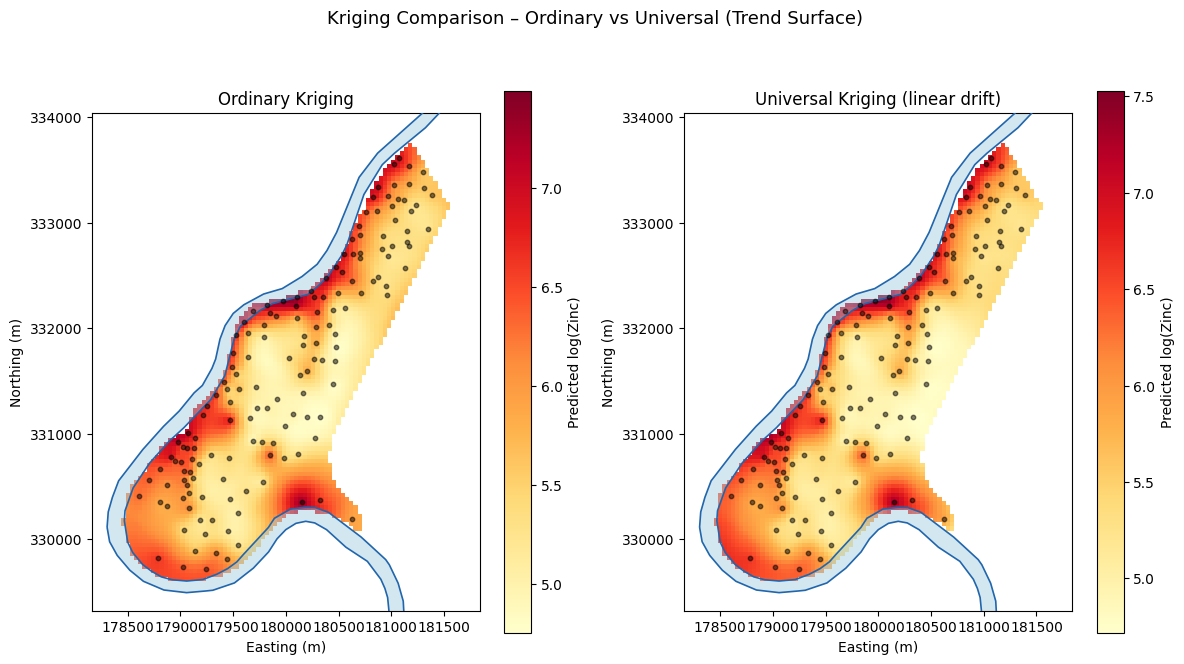

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Part 7 — Universal Kriging / Trend Surface (domain-masked)
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Part 7 — Universal Kriging / Trend Surface (domain-masked)")
print("=" * 60)

from pykrige.uk import UniversalKriging

UK = UniversalKriging(
    x, y, log_z,
    variogram_model='spherical',
    variogram_parameters={'psill': psill, 'range': range_, 'nugget': nugget},
    drift_terms=['regional_linear'],
    verbose=False, enable_plotting=False
)
z_uk, _ = UK.execute('grid', xi, yi)
z_uk = np.where(domain_mask, z_uk, np.nan)
print(f"  Universal Kriging range (in domain): {np.nanmin(z_uk):.3f} – {np.nanmax(z_uk):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
map_plot(axes[0], z_pred, 'YlOrRd', 'Predicted log(Zinc)', 'Ordinary Kriging')
axes[0].scatter(x, y, s=10, c='k', alpha=0.5, zorder=5)
map_plot(axes[1], z_uk,   'YlOrRd', 'Predicted log(Zinc)', 'Universal Kriging (linear drift)')
axes[1].scatter(x, y, s=10, c='k', alpha=0.5, zorder=5)
fig.suptitle('Kriging Comparison – Ordinary vs Universal (Trend Surface)', fontsize=13)
fig.tight_layout()

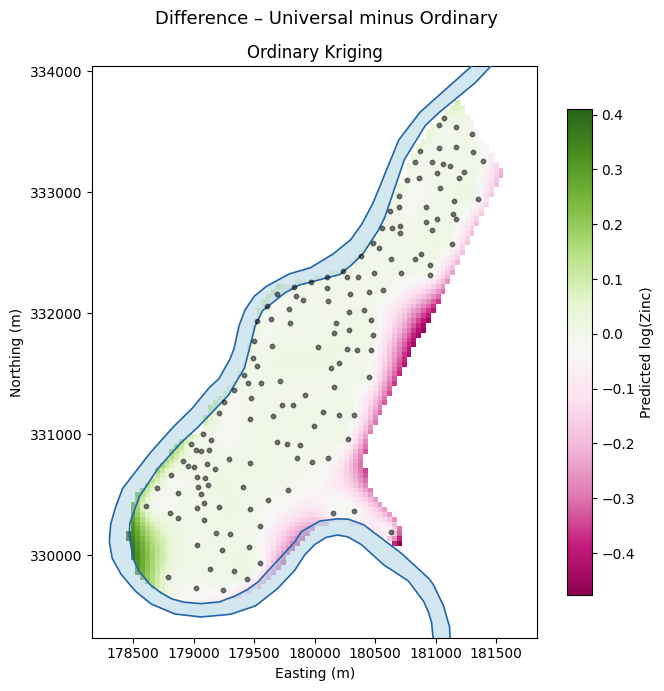

In [11]:
fig, axes = plt.subplots(1, 1, figsize=(7, 7))
map_plot(axes, z_uk - z_pred, 'PiYG', 'Predicted log(Zinc)', 'Ordinary Kriging')
axes.scatter(x, y, s=10, c='k', alpha=0.5, zorder=5)
fig.suptitle('Difference – Universal minus Ordinary', fontsize=13)
fig.tight_layout()